## EDA

In [22]:
import pandas as pd

df= pd.read_excel("Online Retail.xlsx")
df.head

<bound method NDFrame.head of        InvoiceNo StockCode                          Description  Quantity  \
0         536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1         536365     71053                  WHITE METAL LANTERN         6   
2         536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3         536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4         536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   
...          ...       ...                                  ...       ...   
541904    581587     22613          PACK OF 20 SPACEBOY NAPKINS        12   
541905    581587     22899         CHILDREN'S APRON DOLLY GIRL          6   
541906    581587     23254        CHILDRENS CUTLERY DOLLY GIRL          4   
541907    581587     23255      CHILDRENS CUTLERY CIRCUS PARADE         4   
541908    581587     22138        BAKING SET 9 PIECE RETROSPOT          3   

               InvoiceDate  UnitPrice  Custom

In [23]:
# --- Data cleaning pipeline for Online Retail dataset ---

import pandas as pd

# Load data
df = pd.read_excel("Online Retail.xlsx")

# =========================
# BEFORE CLEANING STATISTICS
# =========================
before_rows = len(df)
before_duplicates = df.duplicated().sum()
before_missing_total = df.isna().sum().sum()
before_missing_by_col = df.isna().sum()

# Cancelled invoices: InvoiceNo starts with "C"
before_cancelled = df["InvoiceNo"].astype(str).str.startswith("C", na=False).sum()

# Returned/invalid transaction signals
before_nonpositive_qty = (df["Quantity"] <= 0).sum()
before_nonpositive_price = (df["UnitPrice"] <= 0).sum()

print("=== BEFORE CLEANING ===")
print(f"Rows: {before_rows:,}")
print(f"Exact duplicates: {before_duplicates:,}")
print(f"Total missing values: {before_missing_total:,}")
print("Missing values by column:")
print(before_missing_by_col.to_string())
print(f"Cancelled invoices (InvoiceNo starts with 'C'): {before_cancelled:,}")
print(f"Rows with Quantity <= 0: {before_nonpositive_qty:,}")
print(f"Rows with UnitPrice <= 0: {before_nonpositive_price:,}")
print()

# =========
# CLEANING
# =========

# 1) Remove exact duplicate rows
df_clean = df.drop_duplicates().copy()

# 2) Remove rows with missing values (as requested)
df_clean = df_clean.dropna().copy()

# 3) Remove cancelled transactions
df_clean = df_clean[~df_clean["InvoiceNo"].astype(str).str.startswith("C", na=False)].copy()

# 4) Handle returns/invalid transactions:
#    keep only positive quantity and positive unit price
df_clean = df_clean[(df_clean["Quantity"] > 0) & (df_clean["UnitPrice"] > 0)].copy()

# 5) Create Revenue column
df_clean["Revenue"] = df_clean["Quantity"] * df_clean["UnitPrice"]

# Optional: reset index after filtering
df_clean = df_clean.reset_index(drop=True)

# ========================
# AFTER CLEANING STATISTICS
# ========================
after_rows = len(df_clean)
after_duplicates = df_clean.duplicated().sum()
after_missing_total = df_clean.isna().sum().sum()
after_missing_by_col = df_clean.isna().sum()
after_cancelled = df_clean["InvoiceNo"].astype(str).str.startswith("C", na=False).sum()
after_nonpositive_qty = (df_clean["Quantity"] <= 0).sum()
after_nonpositive_price = (df_clean["UnitPrice"] <= 0).sum()

print("=== AFTER CLEANING ===")
print(f"Rows: {after_rows:,}")
print(f"Exact duplicates: {after_duplicates:,}")
print(f"Total missing values: {after_missing_total:,}")
print("Missing values by column:")
print(after_missing_by_col.to_string())
print(f"Cancelled invoices (InvoiceNo starts with 'C'): {after_cancelled:,}")
print(f"Rows with Quantity <= 0: {after_nonpositive_qty:,}")
print(f"Rows with UnitPrice <= 0: {after_nonpositive_price:,}")
print()

# ======================
# CHANGE SUMMARY
# ======================
print("=== CHANGE SUMMARY ===")
print(f"Rows removed: {before_rows - after_rows:,}")
print(f"Row retention: {after_rows / before_rows:.2%}")
print(f"Total revenue (cleaned data): {df_clean['Revenue'].sum():,.2f}")

# Preview cleaned dataset
df_clean.head()

=== BEFORE CLEANING ===
Rows: 541,909
Exact duplicates: 5,268
Total missing values: 136,534
Missing values by column:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
Cancelled invoices (InvoiceNo starts with 'C'): 9,288
Rows with Quantity <= 0: 10,624
Rows with UnitPrice <= 0: 2,517

=== AFTER CLEANING ===
Rows: 392,692
Exact duplicates: 0
Total missing values: 0
Missing values by column:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
Revenue        0
Cancelled invoices (InvoiceNo starts with 'C'): 0
Rows with Quantity <= 0: 0
Rows with UnitPrice <= 0: 0

=== CHANGE SUMMARY ===
Rows removed: 149,217
Row retention: 72.46%
Total revenue (cleaned data): 8,887,208.89


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


=== MONTHLY SALES & REVENUE TREND ===
   InvoiceYearMonth      Revenue  Quantity  Orders
0           2010-12   570422.730    311048    1400
1           2011-01   568101.310    348473     987
2           2011-02   446084.920    265027     997
3           2011-03   594081.760    347582    1321
4           2011-04   468374.331    291366    1149
5           2011-05   677355.150    372864    1555
6           2011-06   660046.050    363014    1393
7           2011-07   598962.901    367360    1331
8           2011-08   644051.040    397373    1280
9           2011-09   950690.202    543652    1755
10          2011-10  1035642.450    591543    1929
11          2011-11  1156205.610    665923    2657
12          2011-12   517190.440    286777     778

=== DAILY SALES & REVENUE TREND (SAMPLE) ===
   InvoiceDateOnly   Revenue  Quantity  Orders
0       2010-12-01  46192.49     24114     121
1       2010-12-02  47197.57     31077     137
2       2010-12-03  23876.63     11798      57
3       2010-1

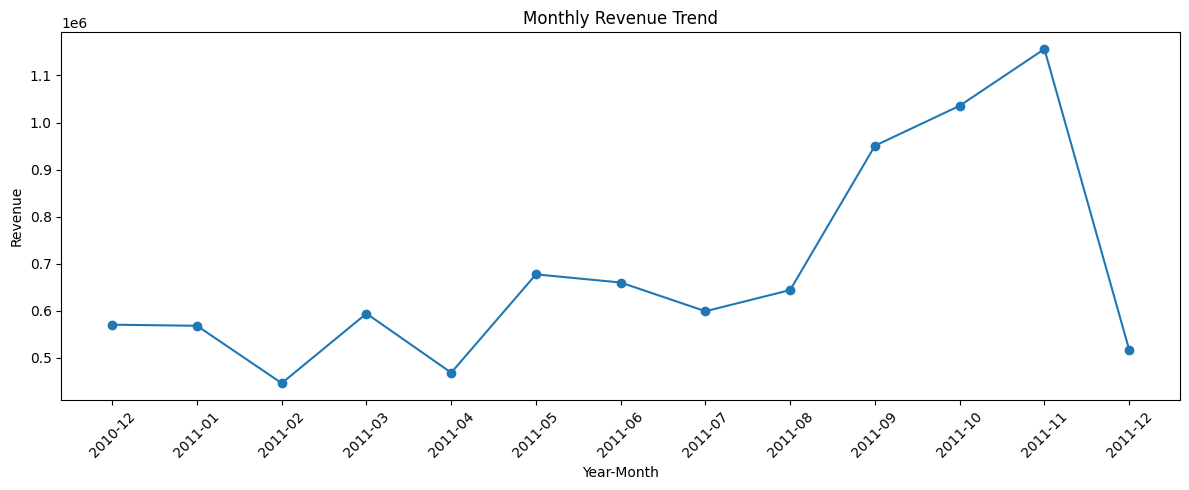

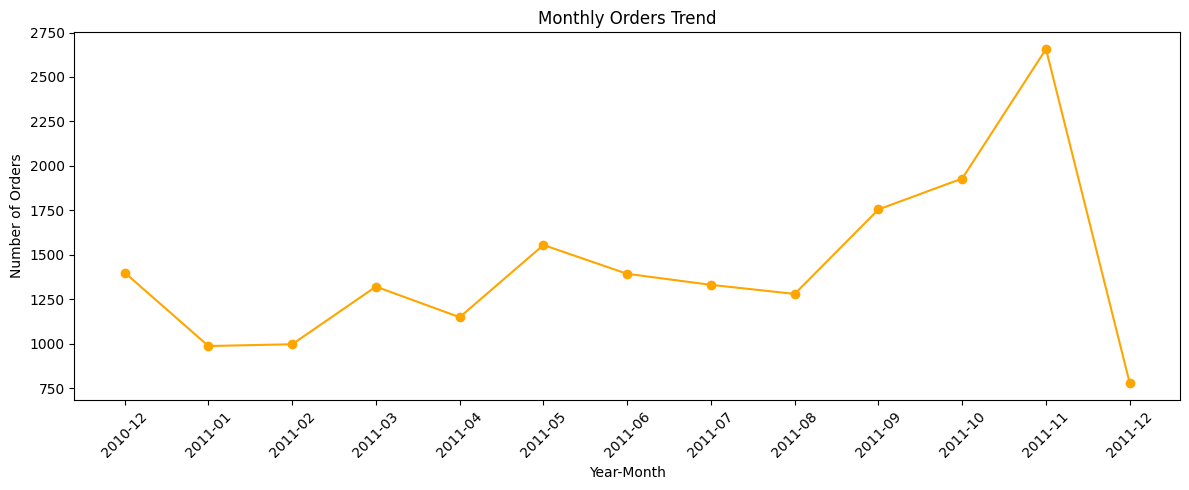

=== COUNTRY METRICS (TOP 20 BY REVENUE) ===
            Country      Revenue  SalesQuantity  Orders          AOV
35   United Kingdom  7285024.644        4241305   16646   437.644157
23      Netherlands   285446.340         200361      94  3036.663191
10             EIRE   265262.460         140133     260  1020.240231
14          Germany   228678.400         119154     457   500.390372
13           France   208934.310         111428     389   537.106195
0         Australia   138453.810          83891      57  2429.014211
30            Spain    61558.560          27933      90   683.984000
32      Switzerland    56443.950          30082      51  1106.744118
3           Belgium    41196.340          23237      98   420.370816
31           Sweden    38367.830          36078      36  1065.773056
19            Japan    37416.370          26016      19  1969.282632
24           Norway    36165.440          19336      36  1004.595556
26         Portugal    33375.840          16095      57   5

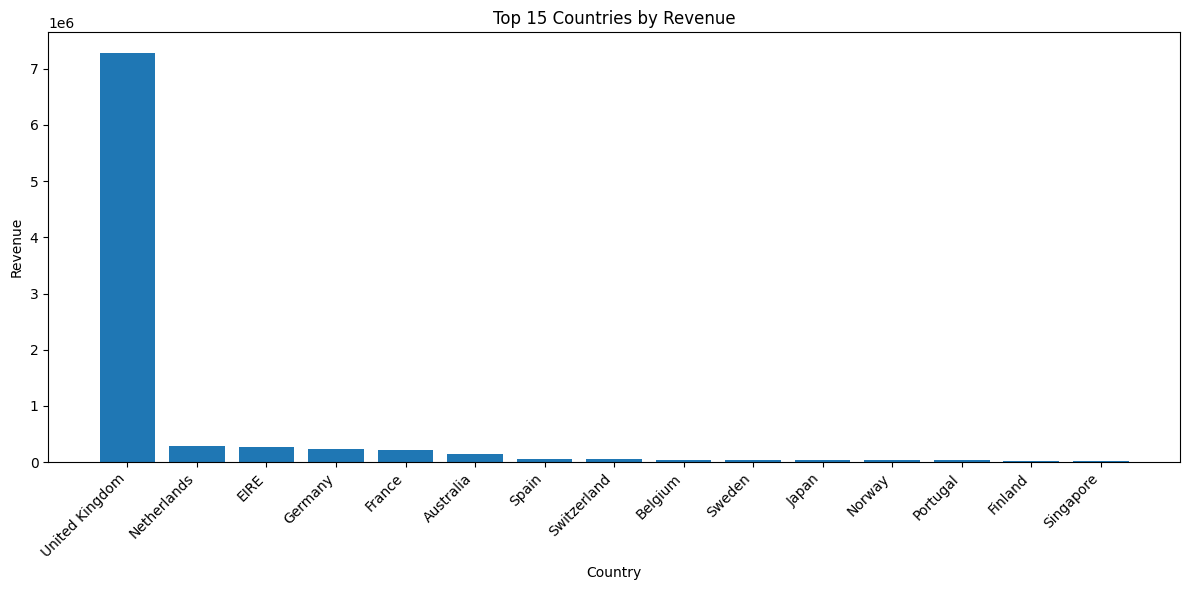

=== TOP 20 PRODUCTS BY REVENUE ===
     StockCode                         Description    Revenue  Quantity  \
2529     23843         PAPER CRAFT , LITTLE BIRDIE  168469.60     80995   
1245     22423            REGENCY CAKESTAND 3 TIER  142264.75     12374   
3576    85123A  WHITE HANGING HEART T-LIGHT HOLDER  100392.10     36706   
3569    85099B             JUMBO BAG RED RETROSPOT   85040.54     46078   
2027     23166      MEDIUM CERAMIC TOP STORAGE JAR   81416.73     77916   
3896      POST                             POSTAGE   77803.96      3120   
2607     47566                       PARTY BUNTING   68785.23     15279   
2810     84879       ASSORTED COLOUR BIRD ORNAMENT   56413.03     35263   
3894         M                              Manual   53419.93      6933   
1933     23084                  RABBIT NIGHT LIGHT   51251.24     27153   
2673     79321                       CHILLI LIGHTS   46265.11      9646   
928      22086     PAPER CHAIN KIT 50'S CHRISTMAS    42584.13    

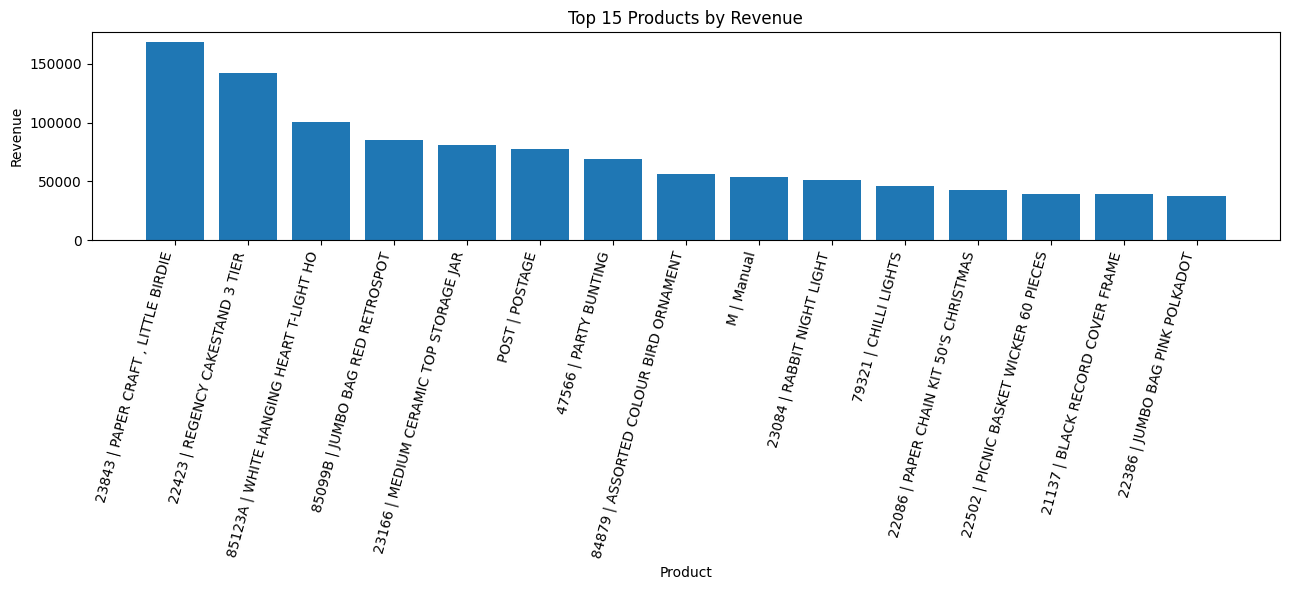

=== ORDER VALUE METRICS ===
Overall AOV: 479.56
Median Order Value: 302.57

=== MONTHLY AOV ===
   InvoiceYearMonth         AOV  MedianOrderValue  Orders
0           2010-12  407.444807           266.050    1400
1           2011-01  575.583901           303.040     987
2           2011-02  447.427202           299.720     997
3           2011-03  449.721241           294.170    1321
4           2011-04  407.636493           301.480    1149
5           2011-05  435.598167           303.610    1555
6           2011-06  473.830617           289.240    1393
7           2011-07  450.009693           302.920    1331
8           2011-08  503.164875           304.795    1280
9           2011-09  541.703819           322.940    1755
10          2011-10  536.880482           314.490    1929
11          2011-11  435.154539           298.850    2657
12          2011-12  664.769203           298.975     778



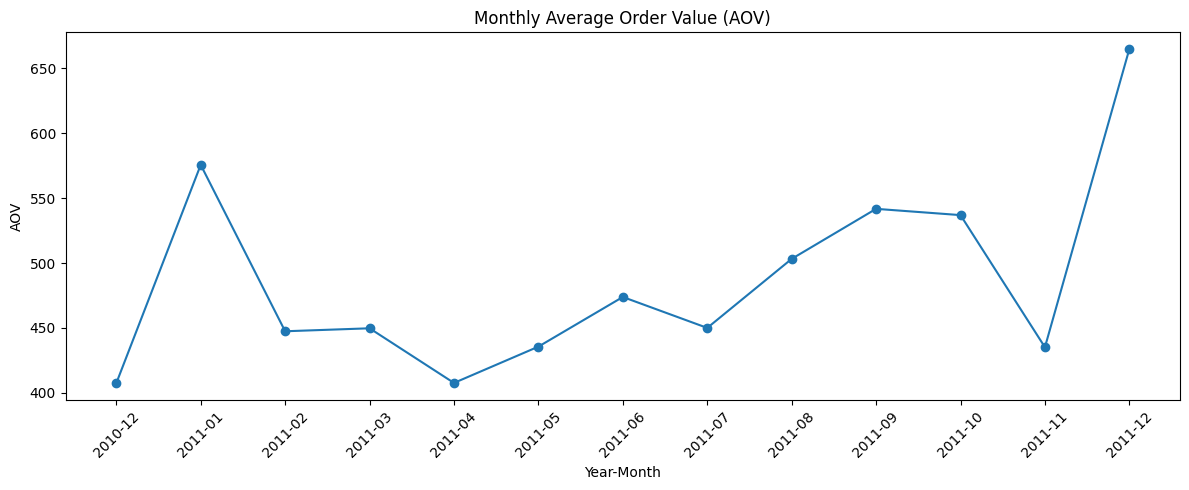

In [24]:
# --- Core business analysis on cleaned dataset (df_clean) ---

import pandas as pd
import matplotlib.pyplot as plt

# Ensure InvoiceDate is datetime
df_clean["InvoiceDate"] = pd.to_datetime(df_clean["InvoiceDate"])

# Create time keys
df_clean["InvoiceYearMonth"] = df_clean["InvoiceDate"].dt.to_period("M").astype(str)
df_clean["InvoiceDateOnly"] = df_clean["InvoiceDate"].dt.date

# ==============================
# 1) SALES & REVENUE OVER TIME
# ==============================

# Monthly trend
monthly_trend = (
    df_clean.groupby("InvoiceYearMonth", as_index=False)
    .agg(
        Revenue=("Revenue", "sum"),
        Quantity=("Quantity", "sum"),
        Orders=("InvoiceNo", "nunique"),
    )
    .sort_values("InvoiceYearMonth")
)

print("=== MONTHLY SALES & REVENUE TREND ===")
print(monthly_trend.head(20))
print()

# Daily trend
daily_trend = (
    df_clean.groupby("InvoiceDateOnly", as_index=False)
    .agg(
        Revenue=("Revenue", "sum"),
        Quantity=("Quantity", "sum"),
        Orders=("InvoiceNo", "nunique"),
    )
    .sort_values("InvoiceDateOnly")
)

print("=== DAILY SALES & REVENUE TREND (SAMPLE) ===")
print(daily_trend.head(20))
print()

# Plot monthly revenue and orders
fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(monthly_trend["InvoiceYearMonth"], monthly_trend["Revenue"], marker="o")
ax1.set_title("Monthly Revenue Trend")
ax1.set_xlabel("Year-Month")
ax1.set_ylabel("Revenue")
ax1.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

fig, ax2 = plt.subplots(figsize=(12, 5))
ax2.plot(monthly_trend["InvoiceYearMonth"], monthly_trend["Orders"], marker="o", color="orange")
ax2.set_title("Monthly Orders Trend")
ax2.set_xlabel("Year-Month")
ax2.set_ylabel("Number of Orders")
ax2.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

# ==========================================================
# 2) GEOGRAPHIC DISTRIBUTION (REVENUE, SALES, AOV BY COUNTRY)
# ==========================================================

country_metrics = (
    df_clean.groupby("Country", as_index=False)
    .agg(
        Revenue=("Revenue", "sum"),
        SalesQuantity=("Quantity", "sum"),
        Orders=("InvoiceNo", "nunique"),
    )
)

country_metrics["AOV"] = country_metrics["Revenue"] / country_metrics["Orders"]
country_metrics = country_metrics.sort_values("Revenue", ascending=False)

print("=== COUNTRY METRICS (TOP 20 BY REVENUE) ===")
print(country_metrics.head(20))
print()

# Optional chart: Top 15 countries by revenue
top15_countries = country_metrics.head(15).copy()
plt.figure(figsize=(12, 6))
plt.bar(top15_countries["Country"], top15_countries["Revenue"])
plt.title("Top 15 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# ===========================
# 3) TOP PERFORMING PRODUCTS
# ===========================

product_metrics = (
    df_clean.groupby(["StockCode", "Description"], as_index=False)
    .agg(
        Revenue=("Revenue", "sum"),
        Quantity=("Quantity", "sum"),
        Orders=("InvoiceNo", "nunique"),
    )
)

top_products_by_revenue = product_metrics.sort_values("Revenue", ascending=False).head(20)
top_products_by_quantity = product_metrics.sort_values("Quantity", ascending=False).head(20)

print("=== TOP 20 PRODUCTS BY REVENUE ===")
print(top_products_by_revenue)
print()

print("=== TOP 20 PRODUCTS BY QUANTITY ===")
print(top_products_by_quantity)
print()

# Optional chart: Top 15 products by revenue
top15_products = top_products_by_revenue.head(15).copy()
top15_products["Label"] = top15_products["StockCode"].astype(str) + " | " + top15_products["Description"].astype(str).str[:30]

plt.figure(figsize=(13, 6))
plt.bar(top15_products["Label"], top15_products["Revenue"])
plt.title("Top 15 Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.show()

# ======================
# 4) AVERAGE ORDER VALUE
# ======================

order_level = (
    df_clean.groupby("InvoiceNo", as_index=False)
    .agg(
        OrderRevenue=("Revenue", "sum"),
        Items=("Quantity", "sum"),
        Lines=("StockCode", "count"),
    )
)

overall_aov = order_level["OrderRevenue"].mean()
median_order_value = order_level["OrderRevenue"].median()

print("=== ORDER VALUE METRICS ===")
print(f"Overall AOV: {overall_aov:,.2f}")
print(f"Median Order Value: {median_order_value:,.2f}")
print()

# AOV over time (monthly)
order_with_month = df_clean[["InvoiceNo", "InvoiceYearMonth"]].drop_duplicates().merge(
    order_level, on="InvoiceNo", how="left"
)

monthly_aov = (
    order_with_month.groupby("InvoiceYearMonth", as_index=False)
    .agg(
        AOV=("OrderRevenue", "mean"),
        MedianOrderValue=("OrderRevenue", "median"),
        Orders=("InvoiceNo", "nunique"),
    )
    .sort_values("InvoiceYearMonth")
)

print("=== MONTHLY AOV ===")
print(monthly_aov)
print()

plt.figure(figsize=(12, 5))
plt.plot(monthly_aov["InvoiceYearMonth"], monthly_aov["AOV"], marker="o")
plt.title("Monthly Average Order Value (AOV)")
plt.xlabel("Year-Month")
plt.ylabel("AOV")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

=== RFM TABLE (HEAD) ===
   CustomerID  Recency  Frequency  Monetary  R_Score  F_Score  M_Score  \
0     12346.0      326          1  77183.60        1        1        5   
1     12347.0        2          7   4310.00        5        5        5   
2     12348.0       75          4   1797.24        2        4        4   
3     12349.0       19          1   1757.55        4        1        4   
4     12350.0      310          1    334.40        1        1        2   

   RFM_Score RFM_Code    Segment  
0          7      115       Lost  
1         15      555  Champions  
2         10      244    At Risk  
3          9      414  Promising  
4          4      112       Lost  

=== SEGMENT SUMMARY ===
               Segment  Customers  Avg_Recency  Avg_Frequency  Avg_Monetary  \
1            Champions       1139    13.311677       9.986831   5191.766533   
0              At Risk        643   152.844479       3.404355   1241.139208   
3      Loyal Customers        321    50.582555       5.682

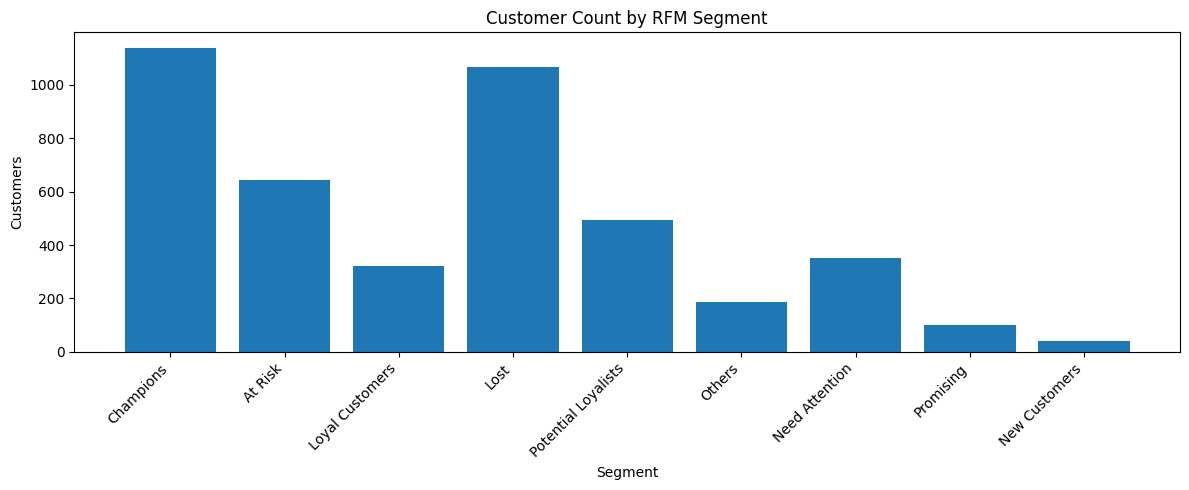

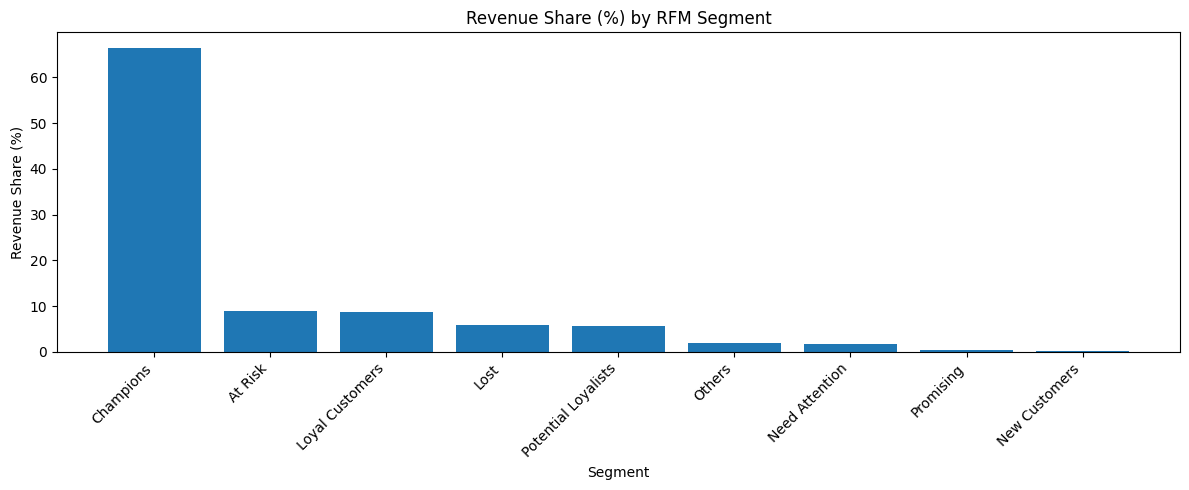

RFM analysis complete. Files saved: rfm_customer_table.csv, rfm_segment_summary.csv


In [25]:
# --- RFM Analysis: Online Retail dataset ---

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 1) Load and clean dataset
# =========================
df = pd.read_excel("Online Retail.xlsx")

# Remove duplicates and missing values
df = df.drop_duplicates().dropna().copy()

# Remove cancelled invoices
df = df[~df["InvoiceNo"].astype(str).str.startswith("C", na=False)].copy()

# Keep only valid positive transactions
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)].copy()

# Create Revenue column
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

# Ensure date type
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

# =========================
# 2) Build RFM base table
# =========================
# Snapshot date = 1 day after the latest transaction
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = (
    df.groupby("CustomerID")
      .agg(
          Recency=("InvoiceDate", lambda x: (snapshot_date - x.max()).days),
          Frequency=("InvoiceNo", "nunique"),
          Monetary=("Revenue", "sum"),
      )
      .reset_index()
)

# =========================
# 3) Score R, F, M (1 to 5)
# =========================
# For Recency: lower days is better => reverse labels (5 best)
rfm["R_Score"] = pd.qcut(
    rfm["Recency"],
    q=5,
    labels=[5, 4, 3, 2, 1],
    duplicates="drop"
).astype(int)

# For Frequency and Monetary: higher is better => normal labels (1 worst, 5 best)
rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    q=5,
    labels=[1, 2, 3, 4, 5],
    duplicates="drop"
).astype(int)

rfm["M_Score"] = pd.qcut(
    rfm["Monetary"].rank(method="first"),
    q=5,
    labels=[1, 2, 3, 4, 5],
    duplicates="drop"
).astype(int)

# Composite scores
rfm["RFM_Score"] = rfm["R_Score"] + rfm["F_Score"] + rfm["M_Score"]
rfm["RFM_Code"] = (
    rfm["R_Score"].astype(str)
    + rfm["F_Score"].astype(str)
    + rfm["M_Score"].astype(str)
)

# ======================================
# 4) Segment customers using R/F patterns
# ======================================
# Segment mapping based on common RFM rules
def rfm_segment(row):
    r, f = row["R_Score"], row["F_Score"]

    if r >= 4 and f >= 4:
        return "Champions"
    elif r >= 3 and f >= 4:
        return "Loyal Customers"
    elif r >= 4 and f >= 2:
        return "Potential Loyalists"
    elif r == 5 and f == 1:
        return "New Customers"
    elif r == 4 and f == 1:
        return "Promising"
    elif r == 3 and f <= 2:
        return "Need Attention"
    elif r <= 2 and f >= 3:
        return "At Risk"
    elif r <= 2 and f <= 2:
        return "Lost"
    else:
        return "Others"

rfm["Segment"] = rfm.apply(rfm_segment, axis=1)

# =========================
# 5) Output core RFM tables
# =========================
print("=== RFM TABLE (HEAD) ===")
print(rfm.head())
print()

segment_summary = (
    rfm.groupby("Segment", as_index=False)
       .agg(
           Customers=("CustomerID", "nunique"),
           Avg_Recency=("Recency", "mean"),
           Avg_Frequency=("Frequency", "mean"),
           Avg_Monetary=("Monetary", "mean"),
           Total_Monetary=("Monetary", "sum"),
       )
       .sort_values("Total_Monetary", ascending=False)
)

segment_summary["CustomerPct"] = (
    segment_summary["Customers"] / segment_summary["Customers"].sum() * 100
)
segment_summary["RevenuePct"] = (
    segment_summary["Total_Monetary"] / segment_summary["Total_Monetary"].sum() * 100
)

print("=== SEGMENT SUMMARY ===")
print(segment_summary)
print()

# =========================
# 6) Optional visualizations
# =========================
# Segment customer count
plt.figure(figsize=(12, 5))
plt.bar(segment_summary["Segment"], segment_summary["Customers"])
plt.title("Customer Count by RFM Segment")
plt.xlabel("Segment")
plt.ylabel("Customers")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Segment revenue share
plt.figure(figsize=(12, 5))
plt.bar(segment_summary["Segment"], segment_summary["RevenuePct"])
plt.title("Revenue Share (%) by RFM Segment")
plt.xlabel("Segment")
plt.ylabel("Revenue Share (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# =========================
# 7) Save outputs (optional)
# =========================
rfm.to_csv("rfm_customer_table.csv", index=False)
segment_summary.to_csv("rfm_segment_summary.csv", index=False)

print("RFM analysis complete. Files saved: rfm_customer_table.csv, rfm_segment_summary.csv")